In [38]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/nkmwicz/data-for-students/refs/heads/main/imdb.csv"
df = pd.read_csv(url)
df.head()

,Unnamed: 0,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,...,Drama,Music,Biography,Romance,History,Crime,Western,War,Musical,Sport
0,0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,...,False,False,False,False,False,False,False,False,False,False
1,1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,...,False,False,False,False,False,False,False,False,False,False
2,2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,...,False,False,False,False,False,False,False,False,False,False
3,3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,...,False,False,False,False,False,False,False,False,False,False
4,4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,...,False,False,False,False,False,False,False,False,False,False


In [39]:
df.shape

(1000, 33)

In [40]:
cats = df["Year"].unique()
cats.sort()
samples = [df.loc[df["Year"] == c, "Rating"] for c in cats]
f, p = stats.f_oneway(*samples)
dfb = len(cats) - 1
dfw = len(df["Rating"]) - len(cats)
alpha = 0.05
crit_f = stats.f.ppf(1-alpha, dfb, dfw)
print(f"f = {f:.4f}, p = {p:.4f}, critical = {crit_f:.4f}")

f = 6.0455, p = 0.0000, critical = 1.8403


In [41]:
tukey = stats.tukey_hsd(*samples)
print(tukey)
cats

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.009     1.000    -0.616     0.598
 (0 - 2)      0.340     0.779    -0.269     0.950
 (0 - 3)      0.164     0.999    -0.448     0.777
 (0 - 4)      0.298     0.870    -0.292     0.889
 (0 - 5)      0.287     0.889    -0.298     0.872
 (0 - 6)      0.200     0.991    -0.383     0.783
 (0 - 7)      0.313     0.751    -0.234     0.859
 (0 - 8)      0.287     0.827    -0.253     0.827
 (0 - 9)      0.523     0.048     0.002     1.043
 (0 - 10)      0.688     0.000     0.208     1.169
 (1 - 0)      0.009     1.000    -0.598     0.616
 (1 - 2)      0.349     0.690    -0.232     0.930
 (1 - 3)      0.173     0.997    -0.411     0.757
 (1 - 4)      0.307     0.799    -0.254     0.868
 (1 - 5)      0.296     0.825    -0.259     0.851
 (1 - 6)      0.209     0.980    -0.344     0.762
 (1 - 7)      0.322     0.635    -0.192     0.836
 (1 - 8)      0.296     0.728    -0.211    

array([2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016])

Text(0.1, 1.05, 'f = 9.7919\np = 0.0000\ncritical = 1.8403')

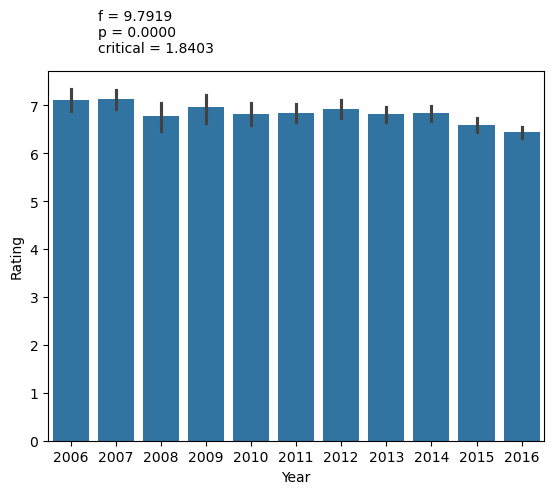

In [49]:
bar = sns.barplot(data=df, x="Year", y="Rating")
text = f"""f = {f:.4f}
p = {p:.4f}
critical = {crit_f:.4f}"""
bar.text(x=0.1, y=1.05, s=text, transform=bar.transAxes)

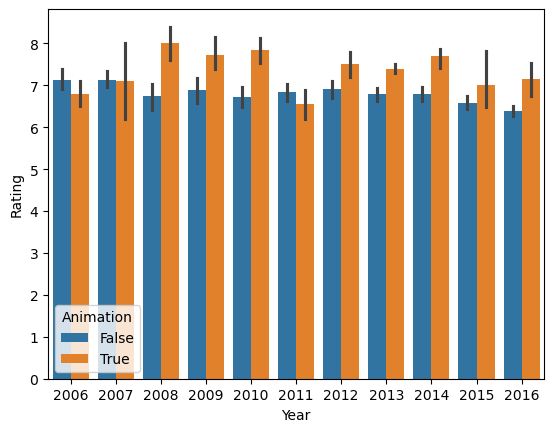

In [43]:
bar = sns.barplot(data=df, x="Year", y="Rating", hue="Animation")

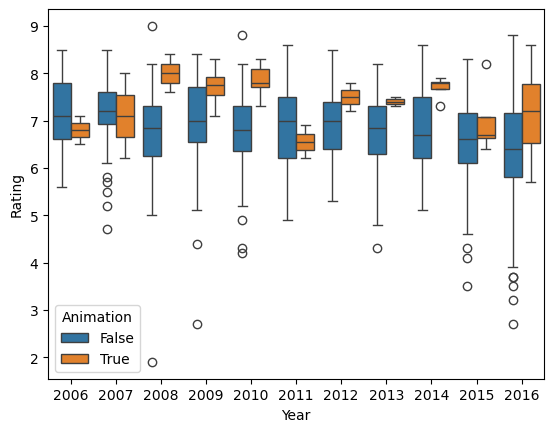

In [44]:
box = sns.boxplot(data=df, x="Year", y="Rating", hue="Animation")

In [45]:
groups = [
    ["Action", "Adventure", "Sci-Fi"],
    ["Drama"],
    ["Comedy", "Romance"],
    ["Animation", "Adventure", "Comedy"]
]
df["Genre"] = df["Genre"].str.split(",")

In [47]:
samples = [df.loc[df["Genre"].apply(lambda x: bool(set(x) & set(g))), "Rating"] for g in groups]
f, p = stats.f_oneway(*samples)
dfb = len(samples) - 1
dfw = sum([len(s) for s in samples]) - len(samples)
cf = stats.f.ppf(1-alpha, dfb, dfw)
text = f"""f={f:.4f}
crit_f={cf:.4f}
p={p:.4f}"""
print(text)

f=9.7919
crit_f=2.6099
p=0.0000


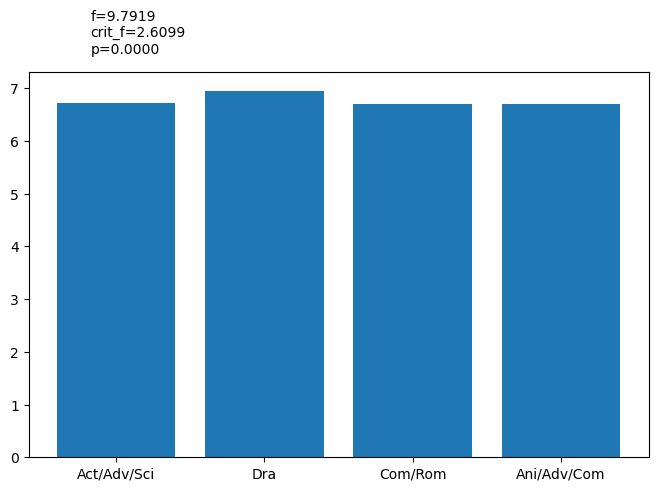

In [48]:
heights = [s.mean() for s in samples]
cols = ["/".join([item[:3] for item in g]) for g in groups]
plt.figure(figsize=(8,5))
plt.bar(x=cols, height=heights)
plt.text(x=0.1, y=1.05, s=text, transform=plt.gca().transAxes)
plt.show()

In [50]:
tukey = stats.tukey_hsd(*samples)
print(tukey)
print(groups)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.241     0.000    -0.390    -0.093
 (0 - 2)      0.009     0.999    -0.155     0.173
 (0 - 3)      0.022     0.983    -0.129     0.172
 (1 - 0)      0.241     0.000     0.093     0.390
 (1 - 2)      0.250     0.000     0.091     0.409
 (1 - 3)      0.263     0.000     0.118     0.408
 (2 - 0)     -0.009     0.999    -0.173     0.155
 (2 - 1)     -0.250     0.000    -0.409    -0.091
 (2 - 3)      0.013     0.997    -0.148     0.174
 (3 - 0)     -0.022     0.983    -0.172     0.129
 (3 - 1)     -0.263     0.000    -0.408    -0.118
 (3 - 2)     -0.013     0.997    -0.174     0.148

[['Action', 'Adventure', 'Sci-Fi'], ['Drama'], ['Comedy', 'Romance'], ['Animation', 'Adventure', 'Comedy']]
